# Chapter 13: Riemannian Metrics

**Source Span inspected.** `Introduction to Smooth Manifolds.pdf`, printed pages `327-348`, using roughly PDF pages `345-366` with `pdftotext`.

**Chapter goal.** Turn a Riemannian metric from a formal symmetric 2-tensor into inspectable geometry: local metric matrices, changing norms and angles, pullback metrics on surfaces, curve length and distance, the tangent-cotangent musical maps, and the pseudo-Riemannian contrast where positivity is lost.

The source is used here only for structure, terminology, theorem orientation, and example coverage. The prose, diagrams, code, and checks are original teaching material intended to stand alone.


## Planner Pass: Visual Storyboard And Library Routing

**Concept inventory.** A Riemannian metric is a smoothly varying positive definite inner product on tangent spaces. In coordinates it is a symmetric positive definite matrix `G(x)`, so vector length, angle, and local area density become `sqrt(v.T @ G @ v)`, the `G`-angle formula, and `sqrt(det(G))`. Pullback metrics are computed by `J.T @ G @ J`; submanifolds inherit metrics by restricting the ambient metric to tangent directions. The distance function is the infimum of curve lengths and is locally comparable to Euclidean distance. The metric also identifies tangent and cotangent bundles by lowering and raising indices. If positivity is replaced by nondegeneracy, pseudo-Riemannian metrics have signatures and null directions, so the Riemannian length and distance story no longer works unchanged.

| Storyboard item | Visual representation | Library route | Inspection target | Validation |
| --- | --- | --- | --- | --- |
| Local metric matrices | Metric unit ellipses, angles, density labels | NumPy + Matplotlib | How `G` changes unit vectors, angle, and local volume scale | eigenvalues positive; ellipse residuals near zero |
| Existence by partitions of unity | Smooth convex patch of two local matrices | NumPy + Matplotlib | Why positive definite metrics survive weighted sums | weights sum to one; minimum eigenvalue positive |
| Pullback and induced metrics | Helicoid surface colored by area density | SymPy + Plotly | `J.T @ J` becomes the induced metric matrix | symbolic residual `J.T J - diag(1,1+u^2)` is zero |
| Length, distance, volume | Conformal density field with approximate shortest paths | SciPy Dijkstra + Matplotlib | Curves measure distance through local norms | positivity and triangle inequality in grid model |
| Musical isomorphisms | Polar-coordinate gradient and contour field | SymPy + Matplotlib | Lowering, raising, and gradient identity | `sharp(flat(X)) = X`, `<grad f,Y> = df(Y)` |
| Pseudo-Riemannian contrast | Light cone and degenerating convex average | NumPy + Matplotlib | Nonzero null vectors and failed partition averaging | determinant vanishes at the averaged Lorentz pair |


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import sympy as sp
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import dijkstra


def locate_book_root() -> Path:
    start = Path.cwd().resolve()
    candidates = [start, *start.parents, start / "Introduction-to-Smooth-Manifolds"]
    for candidate in candidates:
        if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
            return candidate
    for candidate in start.rglob("source_map.json"):
        root = candidate.parent
        if (root / "AGENTS.md").exists() and (root / "utils").exists():
            return root
    raise RuntimeError("Could not locate Introduction-to-Smooth-Manifolds course root")


BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-13-riemannian-metrics"
UNIT_TITLE = "Riemannian Metrics"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"


def rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


np.set_printoptions(precision=4, suppress=True)
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {rel(ARTIFACT_ROOT)}")


Book root: D:\Geometry\Introduction-to-Smooth-Manifolds
Artifact root: artifacts/chapter-13-riemannian-metrics


## Computational Translation Guide

The chapter's formal language can be read as a small computational grammar.

- A Riemannian metric near a chart point is a symmetric positive definite matrix `G(x)`. Positive eigenvalues are the local version of `g_p(v,v) > 0` for nonzero `v`.
- Vector length is `sqrt(v.T @ G @ v)`. Angles use the same inner product, so a coordinate grid can be non-orthogonal even when it looks square on paper.
- Pullbacks and induced metrics are matrix sandwiches. If `F` has Jacobian `J`, the pullback of the Euclidean metric is `J.T @ J`.
- Curve length is the integral of local speed. A distance function is an infimum over such lengths, not an extra structure independent of `g`.
- The flat map sends a vector to a covector with matrix `G`; the sharp map uses `G^{-1}`. This is metric-dependent.
- Pseudo-Riemannian metrics keep nondegeneracy but drop positivity. That creates null directions and blocks the Riemannian proof strategies based on positive norms.


In [2]:
routing_rows = [
    {"concept": "local metric matrices", "representation": "metric ellipses and angle labels", "library": "NumPy + Matplotlib", "why": "eigenvectors and level sets of v.T G v are visible in one chart"},
    {"concept": "partitions of unity", "representation": "smooth weighted matrix patch", "library": "NumPy + Matplotlib", "why": "convex averaging of SPD matrices is a numerical eigenvalue check"},
    {"concept": "pullback and induced metrics", "representation": "helicoid colored by area density", "library": "SymPy + Plotly", "why": "symbolic J.T J plus rotatable 3D surface exposes the submanifold metric"},
    {"concept": "distance function", "representation": "conformal density and graph shortest paths", "library": "SciPy + Matplotlib", "why": "Dijkstra on a small grid makes the infimum-over-curves idea inspectable"},
    {"concept": "musical isomorphisms", "representation": "symbolic polar gradient and vector field", "library": "SymPy + Matplotlib", "why": "raising/lowering indices are exact matrix identities with a visual gradient witness"},
    {"concept": "pseudo-Riemannian contrast", "representation": "light cone and determinant failure", "library": "NumPy + Matplotlib", "why": "signature and null vectors are geometric failure modes, not decoration"},
]

storyboard_rows = [
    {"order": 1, "artifact": "figures/metric-ellipses-local-matrices.png", "learner_target": "Read unit balls, angles, and density from G", "invariant": "SPD eigenvalues and ellipse residuals"},
    {"order": 2, "artifact": "figures/partition-of-unity-positive-metric.png", "learner_target": "See why existence proof uses positive weights", "invariant": "minimum eigenvalue stays positive"},
    {"order": 3, "artifact": "html/helicoid-induced-metric.html", "learner_target": "Connect tangent Jacobian columns to an induced metric", "invariant": "J.T J = diag(1, 1 + u^2)"},
    {"order": 4, "artifact": "figures/distance-volume-density-experiment.png", "learner_target": "Compare straight length with metric-aware paths", "invariant": "grid distances are positive and satisfy triangle inequality"},
    {"order": 5, "artifact": "figures/musical-isomorphism-gradient.png", "learner_target": "Track flat, sharp, and gradient in polar coordinates", "invariant": "sharp(flat(X)) = X and <grad f,Y> = df(Y)"},
    {"order": 6, "artifact": "figures/pseudo-riemannian-light-cones.png", "learner_target": "Separate nondegenerate from positive definite", "invariant": "averaged Lorentz forms become degenerate"},
]

routing_path = save_csv(routing_rows, TABLES / "library-routing.csv")
storyboard_path = save_csv(storyboard_rows, TABLES / "visual-storyboard.csv")
planner_path = save_json({"routing": routing_rows, "storyboard": storyboard_rows}, CHECKS / "chapter-13-storyboard-routing.json")
assert_artifacts([routing_path, storyboard_path, planner_path], min_bytes=80)
display_artifact(storyboard_path)
print(f"Saved planner artifacts: {rel(routing_path)}, {rel(storyboard_path)}")


[visual-storyboard.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/chapter-13-riemannian-metrics/tables/visual-storyboard.csv)

Saved planner artifacts: artifacts/chapter-13-riemannian-metrics/tables/library-routing.csv, artifacts/chapter-13-riemannian-metrics/tables/visual-storyboard.csv


## 1. Local Metrics: Unit Ellipses, Angles, And Density

In coordinates, a Riemannian metric is a smoothly varying symmetric positive definite matrix. The visible object is not the coordinate square; it is the unit set `v.T @ G @ v = 1` in each tangent space. A large eigenvalue makes the unit ellipse short in that eigendirection because moving that way is expensive. A nonzero off-diagonal entry changes the metric angle between coordinate directions.

The square root of the determinant is the local area-density factor for the metric matrix. In later chapters this becomes part of the Riemannian volume form; here it is enough to read it as the amount by which the metric changes infinitesimal area measurements.


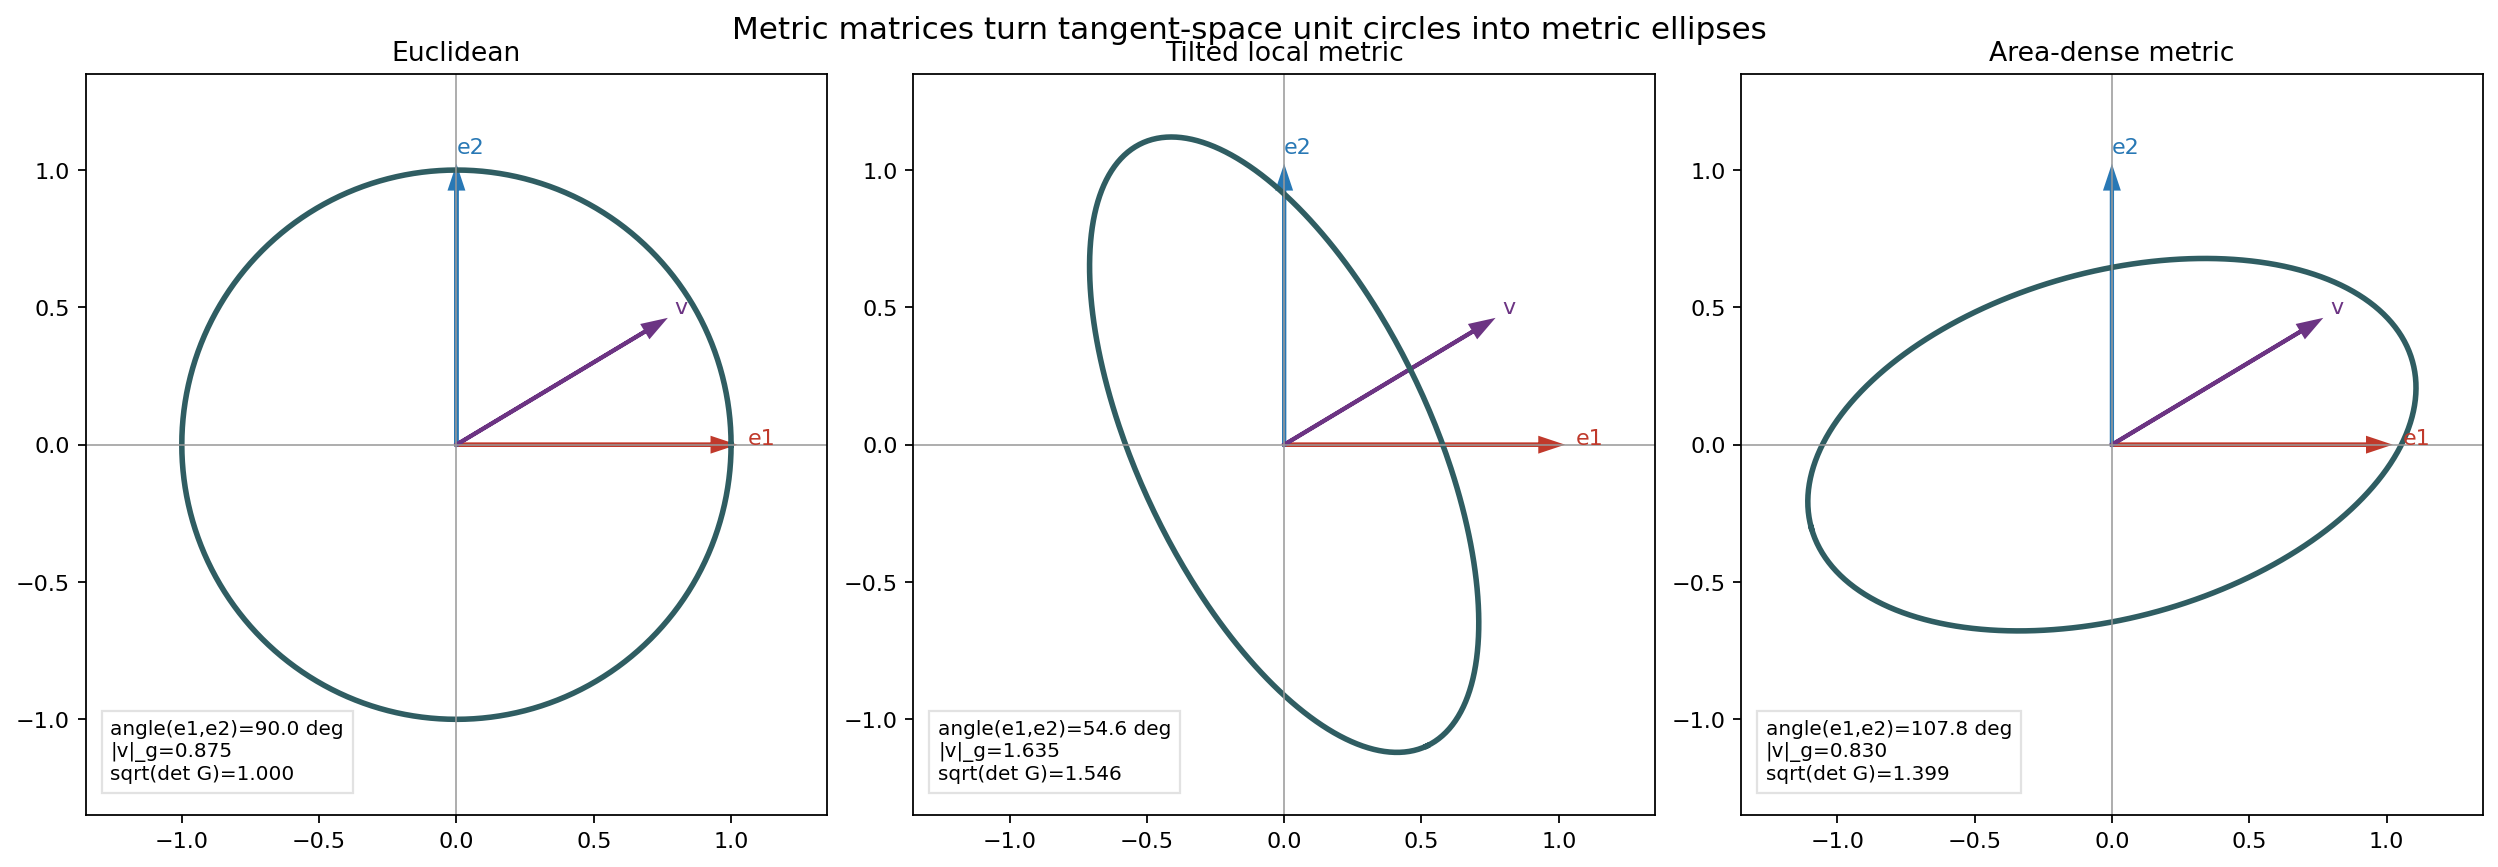

In [3]:
def metric_angle(G: np.ndarray, a: np.ndarray, b: np.ndarray) -> float:
    ip = float(a @ G @ b)
    na = math.sqrt(float(a @ G @ a))
    nb = math.sqrt(float(b @ G @ b))
    return math.degrees(math.acos(np.clip(ip / (na * nb), -1.0, 1.0)))


metric_examples = {
    "Euclidean": np.array([[1.0, 0.0], [0.0, 1.0]]),
    "Tilted local metric": np.array([[3.0, 1.1], [1.1, 1.2]]),
    "Area-dense metric": np.array([[0.9, -0.45], [-0.45, 2.4]]),
}

sample_vectors = {
    "e1": np.array([1.0, 0.0]),
    "e2": np.array([0.0, 1.0]),
    "v": np.array([0.75, 0.45]),
}

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.2), constrained_layout=True)
metric_rows = []
max_unit_residual = 0.0

for ax, (name, G) in zip(axes, metric_examples.items()):
    eigvals, eigvecs = np.linalg.eigh(G)
    axes_lengths = 1.0 / np.sqrt(eigvals)
    theta_values = np.linspace(0, 2 * np.pi, 401)
    circle = np.vstack([np.cos(theta_values), np.sin(theta_values)])
    ellipse = eigvecs @ np.diag(axes_lengths) @ circle
    residual = np.einsum("ij,ji->i", ellipse.T @ G, ellipse)
    max_unit_residual = max(max_unit_residual, float(np.max(np.abs(residual - 1))))

    ax.plot(ellipse[0], ellipse[1], color="#2f5d62", lw=2.5, label="g-unit vectors")
    ax.axhline(0, color="#999999", lw=0.7)
    ax.axvline(0, color="#999999", lw=0.7)
    colors = {"e1": "#c0392b", "e2": "#2878b5", "v": "#6c3483"}
    for label, vec in sample_vectors.items():
        ax.arrow(0, 0, vec[0], vec[1], head_width=0.045, length_includes_head=True, color=colors[label], lw=1.8)
        ax.text(vec[0] * 1.06, vec[1] * 1.06, label, color=colors[label], fontsize=10)
    ax.set_aspect("equal")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_title(name)
    angle = metric_angle(G, sample_vectors["e1"], sample_vectors["e2"])
    density = math.sqrt(float(np.linalg.det(G)))
    norm_v = math.sqrt(float(sample_vectors["v"] @ G @ sample_vectors["v"]))
    ax.text(-1.26, -1.22, f"angle(e1,e2)={angle:0.1f} deg\n|v|_g={norm_v:0.3f}\nsqrt(det G)={density:0.3f}", fontsize=9, bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "#dddddd"})
    metric_rows.append({
        "metric": name,
        "lambda_min": float(eigvals.min()),
        "lambda_max": float(eigvals.max()),
        "angle_e1_e2_deg": angle,
        "norm_sample_v": norm_v,
        "sqrt_det_G": density,
    })

fig.suptitle("Metric matrices turn tangent-space unit circles into metric ellipses", fontsize=14)
metric_ellipse_path = save_matplotlib(fig, FIGURES / "metric-ellipses-local-matrices.png")
plt.close(fig)
metric_table_path = save_csv(metric_rows, TABLES / "metric-matrix-local-data.csv")
metric_checks = {
    "all_metric_matrices_spd": all(row["lambda_min"] > 0 for row in metric_rows),
    "max_unit_ellipse_residual": max_unit_residual,
    "rows": metric_rows,
}
metric_checks_path = save_json(metric_checks, CHECKS / "metric-ellipse-invariants.json")
assert metric_checks["all_metric_matrices_spd"]
assert metric_checks["max_unit_ellipse_residual"] < 1e-12
display_artifact(metric_ellipse_path, width=980)


## 2. Existence: Why The Partition-Of-Unity Patch Stays Positive

The existence proof for Riemannian metrics relies on one convexity fact: a positive weighted average of positive definite inner products is still positive definite. A partition of unity supplies smooth nonnegative weights that sum to one near every point. The next cell models the proof on a line of chart overlap by smoothly blending two local metric matrices.

The plot is not a proof by itself; it is a diagnostic for the proof. If the weights were allowed to be negative, or if the local forms were not positive definite, the eigenvalue floor could cross zero.


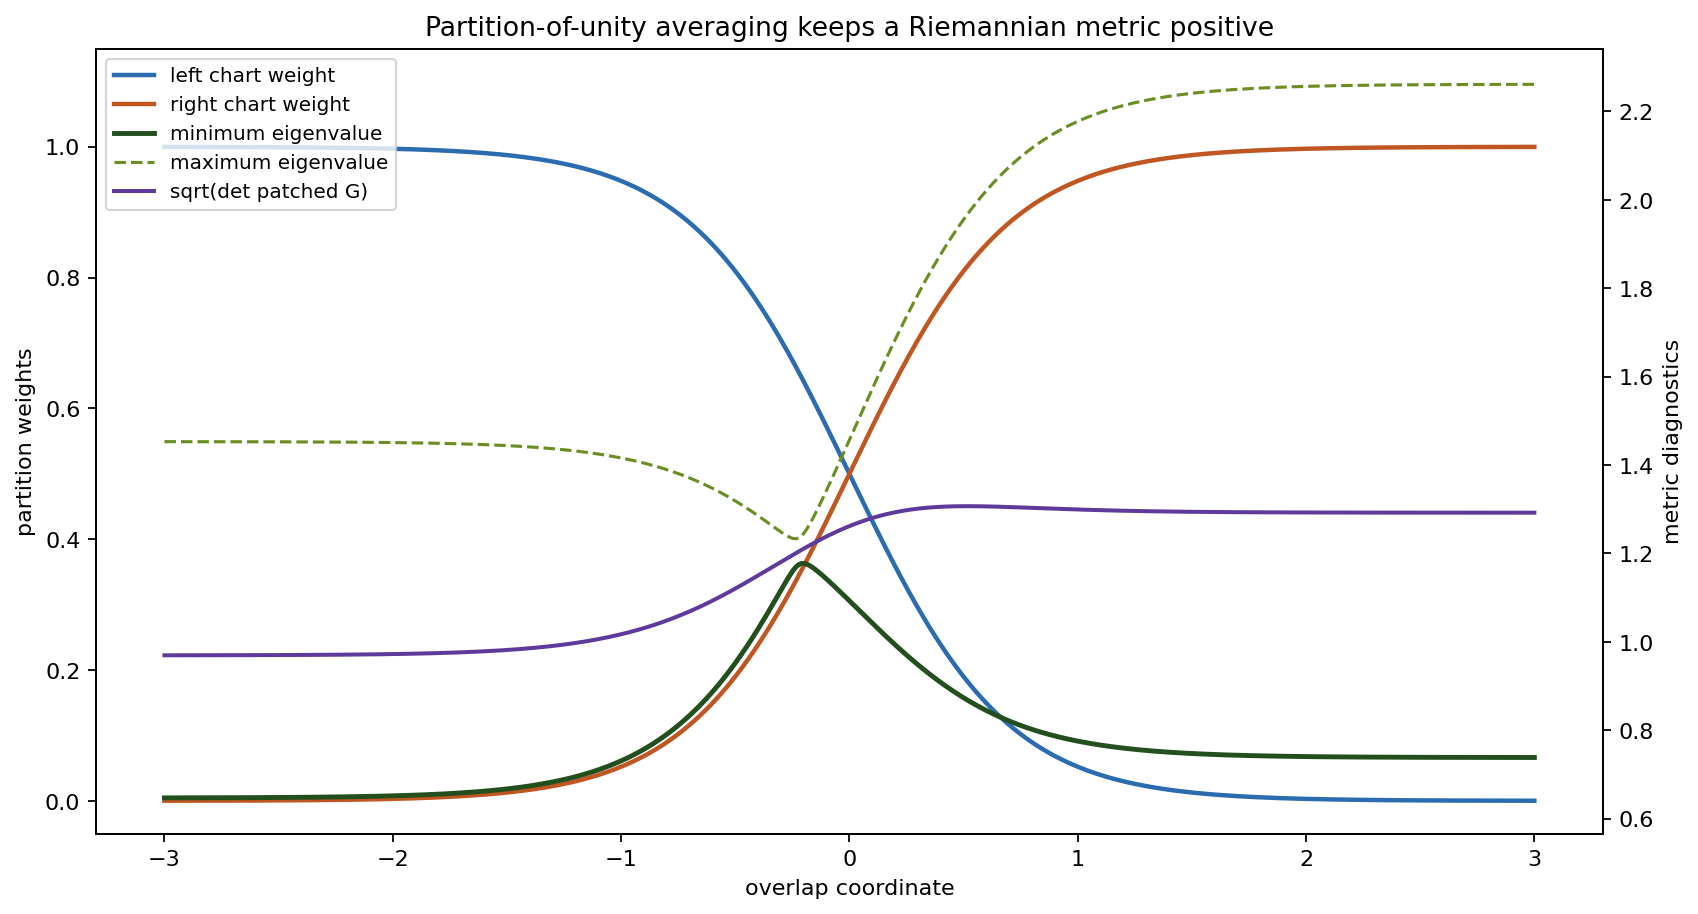

In [4]:
x_grid = np.linspace(-3.0, 3.0, 500)
weight_right = 0.5 * (1.0 + np.tanh(1.45 * x_grid))
weight_left = 1.0 - weight_right
G_left = np.array([[1.4, 0.2], [0.2, 0.7]])
G_right = np.array([[0.8, -0.3], [-0.3, 2.2]])

patched_eigs = []
patched_det = []
for wl, wr in zip(weight_left, weight_right):
    Gx = wl * G_left + wr * G_right
    patched_eigs.append(np.linalg.eigvalsh(Gx))
    patched_det.append(np.linalg.det(Gx))
patched_eigs = np.array(patched_eigs)
patched_det = np.array(patched_det)

fig, ax1 = plt.subplots(figsize=(10.5, 5.6), constrained_layout=True)
ax1.plot(x_grid, weight_left, color="#2b6cb0", lw=2, label="left chart weight")
ax1.plot(x_grid, weight_right, color="#c05621", lw=2, label="right chart weight")
ax1.set_xlabel("overlap coordinate")
ax1.set_ylabel("partition weights")
ax1.set_ylim(-0.05, 1.15)
ax2 = ax1.twinx()
ax2.plot(x_grid, patched_eigs[:, 0], color="#234f1e", lw=2.2, label="minimum eigenvalue")
ax2.plot(x_grid, patched_eigs[:, 1], color="#6b8e23", lw=1.4, ls="--", label="maximum eigenvalue")
ax2.plot(x_grid, np.sqrt(patched_det), color="#5d3a9b", lw=1.8, label="sqrt(det patched G)")
ax2.set_ylabel("metric diagnostics")
ax1.set_title("Partition-of-unity averaging keeps a Riemannian metric positive")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="upper left", fontsize=9)
partition_path = save_matplotlib(fig, FIGURES / "partition-of-unity-positive-metric.png")
plt.close(fig)
partition_checks = {
    "weights_sum_to_one_max_error": float(np.max(np.abs(weight_left + weight_right - 1.0))),
    "weights_nonnegative": bool(np.min(weight_left) >= 0 and np.min(weight_right) >= 0),
    "minimum_patched_eigenvalue": float(patched_eigs[:, 0].min()),
    "minimum_patched_determinant": float(patched_det.min()),
}
partition_checks_path = save_json(partition_checks, CHECKS / "partition-of-unity-positive-metric.json")
assert partition_checks["weights_sum_to_one_max_error"] < 1e-14
assert partition_checks["weights_nonnegative"]
assert partition_checks["minimum_patched_eigenvalue"] > 0
display_artifact(partition_path, width=860)


## 3. Pullback And Induced Metrics: A Helicoid As A Metric Matrix

For an immersion into Euclidean space, the pullback metric is the Gram matrix of the tangent vectors supplied by the Jacobian. This makes the pullback criterion concrete: if the Jacobian columns are linearly independent, their Gram matrix is positive definite.

The surface below uses the parametrization `F(u,v) = (u cos v, u sin v, v)`. The computation checks that the induced metric is diagonal with entries `1` and `1 + u^2`. Rotating the HTML surface helps tie the matrix entry `1 + u^2` to the growing length of the helical direction away from the axis.


In [5]:
u, v = sp.symbols("u v", real=True)
F = sp.Matrix([u * sp.cos(v), u * sp.sin(v), v])
J = F.jacobian([u, v])
helicoid_metric = sp.simplify(J.T * J)
helicoid_expected = sp.Matrix([[1, 0], [0, 1 + u**2]])
helicoid_residual = sp.simplify(helicoid_metric - helicoid_expected)
helicoid_det = sp.factor(helicoid_metric.det())

u_vals = np.linspace(-2.2, 2.2, 80)
v_vals = np.linspace(-2.5 * np.pi, 2.5 * np.pi, 150)
U, V = np.meshgrid(u_vals, v_vals)
X = U * np.cos(V)
Y = U * np.sin(V)
Z = V
area_density = np.sqrt(1.0 + U**2)

fig = go.Figure(data=[go.Surface(x=X, y=Y, z=Z, surfacecolor=area_density, colorscale="Viridis", colorbar={"title": "sqrt(det G)"})])
fig.update_layout(
    title="Helicoid pullback metric: G = J.T J = diag(1, 1 + u^2)",
    scene={"xaxis_title": "x", "yaxis_title": "y", "zaxis_title": "z", "aspectmode": "data"},
    margin={"l": 0, "r": 0, "t": 45, "b": 0},
)
helicoid_html_path = HTML / "helicoid-induced-metric.html"
fig.write_html(str(helicoid_html_path), include_plotlyjs=True, full_html=True)
helicoid_checks = {
    "metric_matrix": str(helicoid_metric),
    "determinant": str(helicoid_det),
    "symbolic_residual_zero": helicoid_residual == sp.zeros(2),
    "sample_minimum_eigenvalue": float(min(np.linalg.eigvalsh(np.array([[1.0, 0.0], [0.0, 1.0 + uu**2]])).min() for uu in u_vals)),
    "area_density_min": float(area_density.min()),
    "area_density_max": float(area_density.max()),
}
helicoid_checks_path = save_json(helicoid_checks, CHECKS / "helicoid-induced-metric-symbolic.json")
assert helicoid_checks["symbolic_residual_zero"]
assert helicoid_checks["sample_minimum_eigenvalue"] > 0
display_artifact(helicoid_html_path, width=900, height=560)
print(f"Induced metric: {helicoid_metric}")


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Induced metric: Matrix([[1, 0], [0, u**2 + 1]])


## 4. Length And Distance: Curves As Measuring Tapes

Once a metric gives the speed of a curve, length is obtained by integrating speed. The distance between two points is the infimum of lengths over all piecewise smooth curves joining them. The next experiment uses a conformal metric `g = lambda(x,y)^2 (dx^2 + dy^2)`. Darker regions have larger local area density `lambda^2`, and crossing them costs more length.

The Dijkstra path is a finite graph approximation to the infimum. It should not be mistaken for a geodesic theorem; it is a small inspection model for positivity, symmetry, and the triangle inequality behind the distance-function construction.


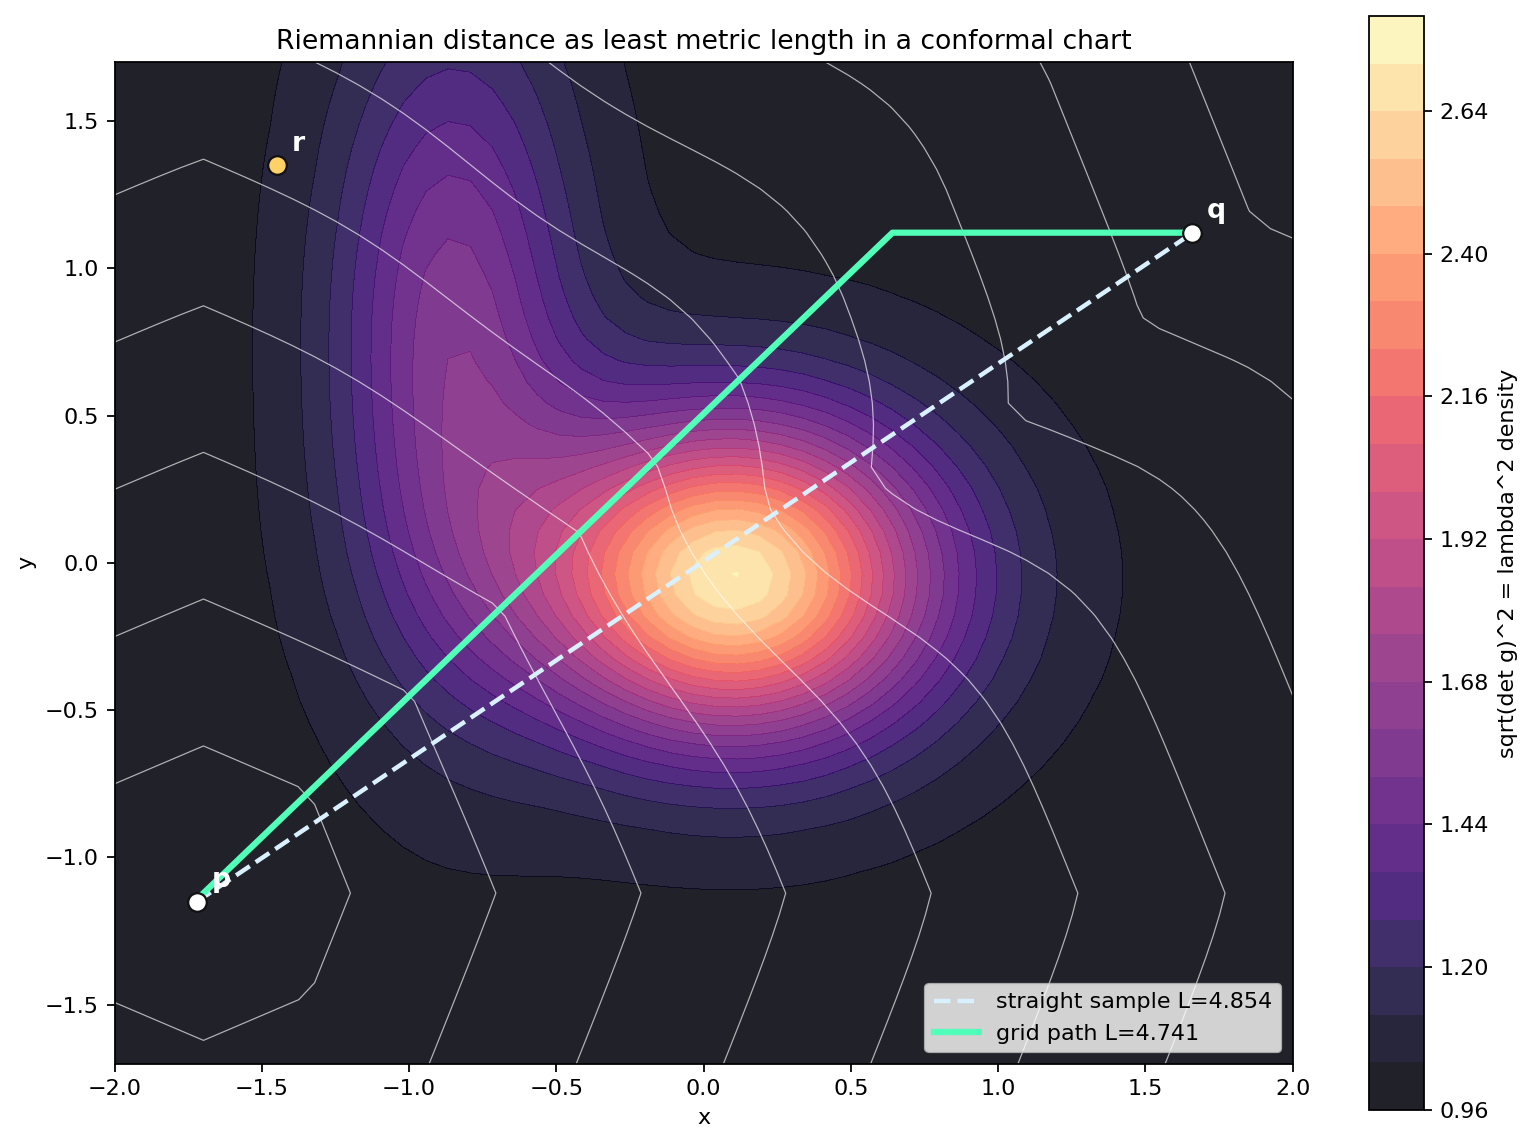

In [6]:
def lambda_metric(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    bump = np.exp(-((x - 0.1) ** 2 / 0.5 + (y + 0.05) ** 2 / 0.32))
    ridge = 0.25 * np.exp(-((x + 0.85) ** 2 / 0.18 + (y - 0.8) ** 2 / 1.2))
    return 1.0 + 0.65 * bump + ridge


def nearest_grid_index(point, xs, ys):
    ix = int(np.argmin(np.abs(xs - point[0])))
    iy = int(np.argmin(np.abs(ys - point[1])))
    return iy * len(xs) + ix


def index_to_point(index, xs, ys):
    iy, ix = divmod(int(index), len(xs))
    return np.array([xs[ix], ys[iy]])


def recover_path(predecessors, source, target, xs, ys):
    path = [target]
    current = target
    while current != source:
        current = int(predecessors[current])
        if current < 0:
            raise RuntimeError("No predecessor path found")
        path.append(current)
    path.reverse()
    return np.vstack([index_to_point(idx, xs, ys) for idx in path])


def polyline_length(points):
    total = 0.0
    for a, b in zip(points[:-1], points[1:]):
        mid = 0.5 * (a + b)
        total += float(lambda_metric(mid[0], mid[1]) * np.linalg.norm(b - a))
    return total


xs = np.linspace(-2.0, 2.0, 54)
ys = np.linspace(-1.7, 1.7, 48)
XX, YY = np.meshgrid(xs, ys)
density = lambda_metric(XX, YY) ** 2
n_x, n_y = len(xs), len(ys)
rows, cols, data = [], [], []
neighbors = [(1, 0), (0, 1), (1, 1), (1, -1)]
for iy in range(n_y):
    for ix in range(n_x):
        i = iy * n_x + ix
        p = np.array([xs[ix], ys[iy]])
        for dx, dy in neighbors:
            jx, jy = ix + dx, iy + dy
            if 0 <= jx < n_x and 0 <= jy < n_y:
                j = jy * n_x + jx
                q = np.array([xs[jx], ys[jy]])
                mid = 0.5 * (p + q)
                weight = float(lambda_metric(mid[0], mid[1]) * np.linalg.norm(q - p))
                rows.extend([i, j])
                cols.extend([j, i])
                data.extend([weight, weight])

graph = coo_matrix((data, (rows, cols)), shape=(n_x * n_y, n_x * n_y)).tocsr()
P = np.array([-1.72, -1.15])
Q = np.array([1.66, 1.12])
R = np.array([-1.45, 1.35])
p_idx = nearest_grid_index(P, xs, ys)
q_idx = nearest_grid_index(Q, xs, ys)
r_idx = nearest_grid_index(R, xs, ys)
source_distances, predecessor_matrix = dijkstra(graph, directed=False, indices=[p_idx, q_idx, r_idx], return_predecessors=True)
path_pq = recover_path(predecessor_matrix[0], p_idx, q_idx, xs, ys)
blend = np.linspace(0, 1, 160)[:, None]
straight_samples = blend * Q + (1 - blend) * P
straight_length = polyline_length(straight_samples)
grid_path_length = polyline_length(path_pq)

tri_pq = float(source_distances[0, q_idx])
tri_qr = float(source_distances[1, r_idx])
tri_pr = float(source_distances[0, r_idx])
triangle_slack = tri_pq + tri_qr - tri_pr

fig, ax = plt.subplots(figsize=(9.5, 7.2), constrained_layout=True)
cf = ax.contourf(XX, YY, density, levels=24, cmap="magma", alpha=0.88)
fig.colorbar(cf, ax=ax, label="sqrt(det g)^2 = lambda^2 density")
ax.contour(XX, YY, source_distances[0].reshape(n_y, n_x), levels=12, colors="white", linewidths=0.55, alpha=0.65)
ax.plot(straight_samples[:, 0], straight_samples[:, 1], color="#d9f0ff", lw=2.0, ls="--", label=f"straight sample L={straight_length:0.3f}")
ax.plot(path_pq[:, 0], path_pq[:, 1], color="#52ffb8", lw=2.8, label=f"grid path L={grid_path_length:0.3f}")
for label, point, color in [("p", P, "#ffffff"), ("q", Q, "#ffffff"), ("r", R, "#ffd166")]:
    ax.scatter([point[0]], [point[1]], s=70, c=color, edgecolor="#111111", zorder=5)
    ax.text(point[0] + 0.05, point[1] + 0.05, label, color="#ffffff", fontsize=12, weight="bold")
ax.set_title("Riemannian distance as least metric length in a conformal chart")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.legend(loc="lower right")
distance_path = save_matplotlib(fig, FIGURES / "distance-volume-density-experiment.png")
plt.close(fig)

distance_checks = {
    "straight_curve_length": straight_length,
    "grid_shortest_path_length": grid_path_length,
    "d_pq": tri_pq,
    "d_qr": tri_qr,
    "d_pr": tri_pr,
    "triangle_slack_dpq_plus_dqr_minus_dpr": triangle_slack,
    "all_sampled_density_positive": bool(np.min(density) > 0),
    "density_min": float(np.min(density)),
    "density_max": float(np.max(density)),
    "grid_path_no_longer_than_straight_sample": bool(grid_path_length <= straight_length + 0.35),
}
distance_checks_path = save_json(distance_checks, CHECKS / "distance-volume-density-checks.json")
assert distance_checks["all_sampled_density_positive"]
assert tri_pq > 0 and tri_qr > 0 and tri_pr > 0
assert triangle_slack >= -1e-10
display_artifact(distance_path, width=820)


## 5. Tangent-Cotangent Musical Maps And The Gradient

A metric turns a vector into a covector by inserting the vector into the first slot of the inner product. In coordinates, this is multiplication by `G`; the inverse operation uses `G^{-1}`. That is the whole meaning of lowering and raising an index.

The gradient is the sharp of `df`. The polar-coordinate example below is useful because the Euclidean metric is not the identity matrix in the coordinate basis: `G = diag(1, r^2)`. The symbolic check verifies the defining identity `<grad f, Y>_g = df(Y)`, while the plot shows the resulting vector field crossing the level curves of `f`.


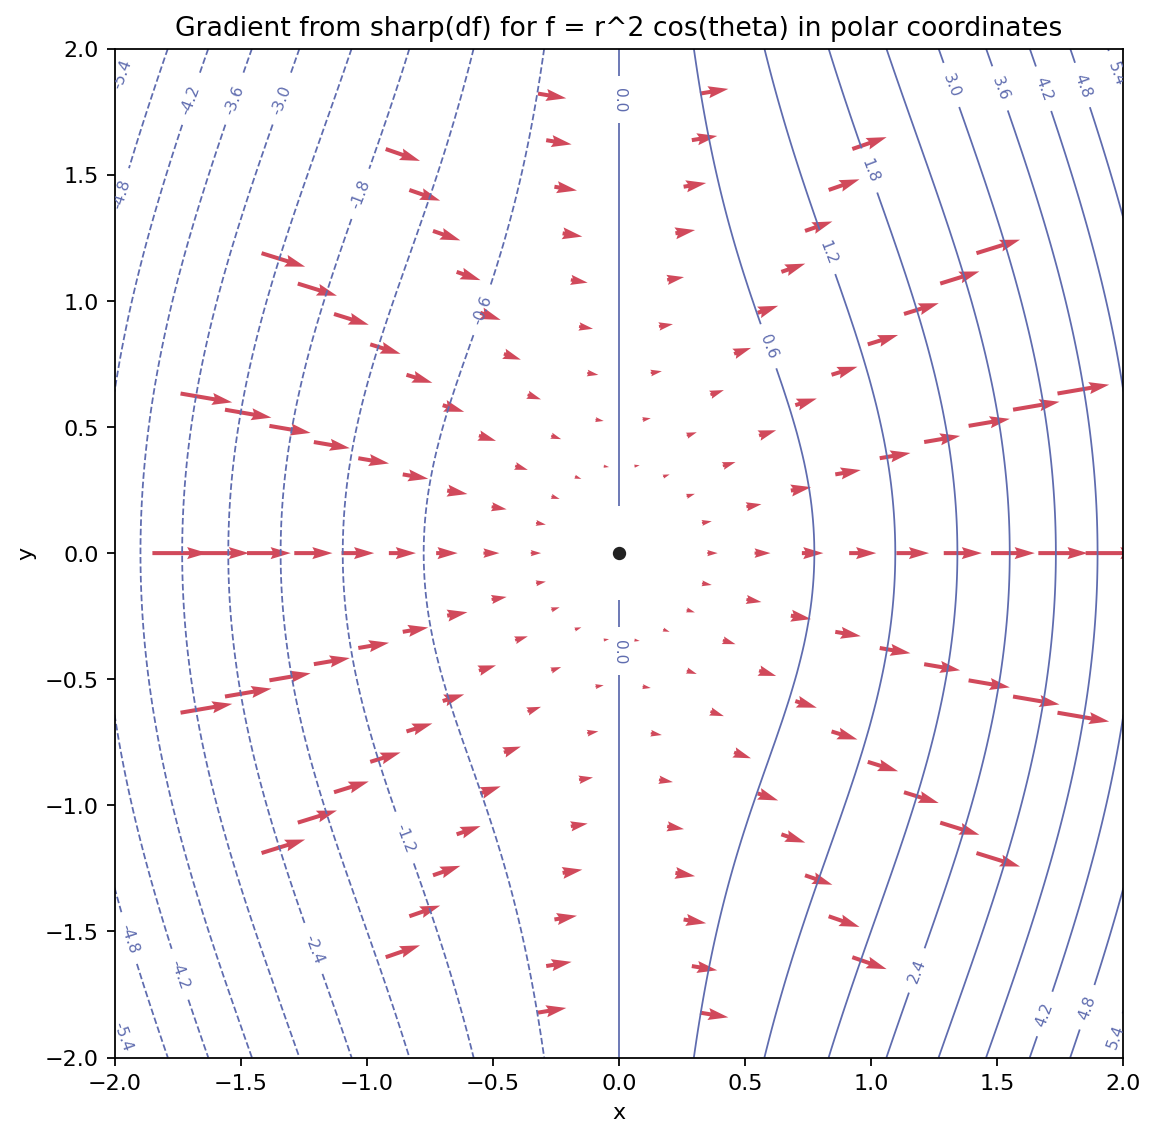

grad f in polar coordinate basis: Matrix([[2*r*cos(theta)], [-sin(theta)]])


In [7]:
r, theta = sp.symbols("r theta", positive=True, real=True)
A, B, C, D = sp.symbols("A B C D", real=True)
G_polar = sp.Matrix([[1, 0], [0, r**2]])
G_polar_inv = G_polar.inv()
X_vec = sp.Matrix([A, B])
Y_vec = sp.Matrix([C, D])
flat_X = G_polar * X_vec
sharp_flat_X = sp.simplify(G_polar_inv * flat_X)
f_expr = r**2 * sp.cos(theta)
df_expr = sp.Matrix([sp.diff(f_expr, r), sp.diff(f_expr, theta)])
grad_f = sp.simplify(G_polar_inv * df_expr)
grad_identity_residual = sp.simplify((grad_f.T * G_polar * Y_vec)[0] - (df_expr.T * Y_vec)[0])
round_trip_residual = sp.simplify(sharp_flat_X - X_vec)

x_plot = np.linspace(-2.0, 2.0, 140)
y_plot = np.linspace(-2.0, 2.0, 140)
Xc, Yc = np.meshgrid(x_plot, y_plot)
Rc = np.sqrt(Xc**2 + Yc**2)
Th = np.arctan2(Yc, Xc)
Fvals = Rc**2 * np.cos(Th)
Fvals[Rc < 0.18] = np.nan

qr = np.linspace(0.35, 1.85, 9)
qt = np.linspace(0, 2 * np.pi, 18, endpoint=False)
RR, TT = np.meshgrid(qr, qt)
PX = RR * np.cos(TT)
PY = RR * np.sin(TT)
grad_r = 2 * RR * np.cos(TT)
grad_theta_coord = -np.sin(TT)
VX = grad_r * np.cos(TT) + grad_theta_coord * RR * (-np.sin(TT))
VY = grad_r * np.sin(TT) + grad_theta_coord * RR * np.cos(TT)

fig, ax = plt.subplots(figsize=(7.6, 7.0), constrained_layout=True)
contours = ax.contour(Xc, Yc, Fvals, levels=18, colors="#5f6caf", linewidths=0.8)
ax.clabel(contours, inline=True, fontsize=7, fmt="%0.1f")
ax.quiver(PX, PY, VX, VY, color="#d1495b", angles="xy", scale_units="xy", scale=17, width=0.004)
ax.scatter([0], [0], s=25, color="#222222")
ax.set_aspect("equal")
ax.set_title("Gradient from sharp(df) for f = r^2 cos(theta) in polar coordinates")
ax.set_xlabel("x")
ax.set_ylabel("y")
musical_path = save_matplotlib(fig, FIGURES / "musical-isomorphism-gradient.png")
plt.close(fig)
musical_checks = {
    "polar_metric": str(G_polar),
    "flat_X_components": [str(component) for component in flat_X],
    "grad_f_components_in_coordinate_basis": [str(component) for component in grad_f],
    "sharp_flat_round_trip_zero": round_trip_residual == sp.zeros(2, 1),
    "gradient_identity_residual": str(grad_identity_residual),
    "gradient_identity_zero": grad_identity_residual == 0,
}
musical_checks_path = save_json(musical_checks, CHECKS / "musical-isomorphism-symbolic.json")
assert musical_checks["sharp_flat_round_trip_zero"]
assert musical_checks["gradient_identity_zero"]
display_artifact(musical_path, width=720)
print(f"grad f in polar coordinate basis: {grad_f}")


## 6. Pseudo-Riemannian Metrics: Nondegenerate Is Not Positive

A pseudo-Riemannian metric is still symmetric and nondegenerate, but it does not assign positive squared length to every nonzero vector. In the two-dimensional Lorentz model, nonzero null vectors have zero squared length. That single fact breaks the Riemannian norm, angle, and distance constructions that relied on positive definiteness.

The second panel shows a related pitfall for existence arguments: a positive weighted average of nondegenerate forms need not be nondegenerate. Averaging the two opposite Lorentz signatures shown there produces the zero matrix at the midpoint.


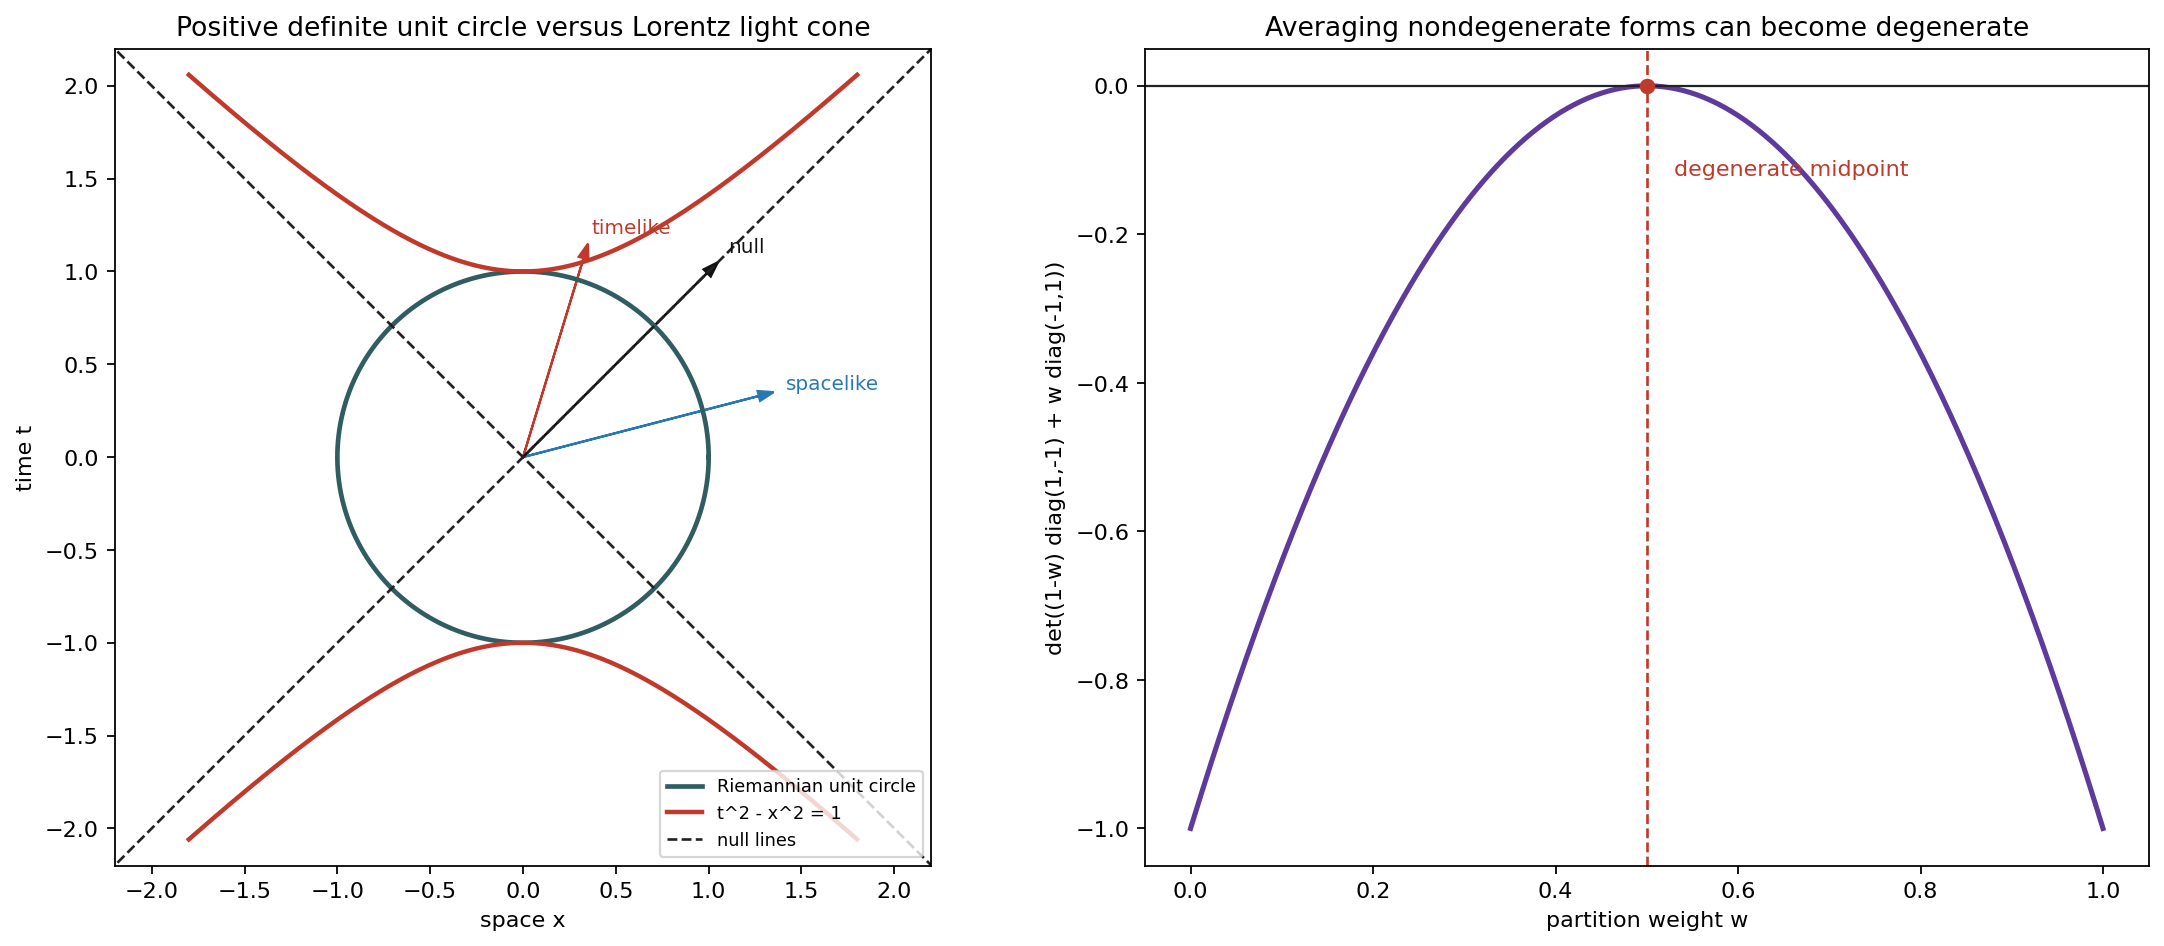

In [8]:
s = np.linspace(-2.4, 2.4, 400)
lorentz_weight = np.linspace(0, 1, 401)
lorentz_det = -((1 - 2 * lorentz_weight) ** 2)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13.5, 5.8), constrained_layout=True)
ang = np.linspace(0, 2 * np.pi, 400)
ax0.plot(np.cos(ang), np.sin(ang), color="#2f5d62", lw=2.1, label="Riemannian unit circle")
h = np.linspace(-1.8, 1.8, 300)
t_pos = np.sqrt(1 + h**2)
ax0.plot(h, t_pos, color="#c0392b", lw=2.0, label="t^2 - x^2 = 1")
ax0.plot(h, -t_pos, color="#c0392b", lw=2.0)
ax0.plot(s, s, color="#222222", lw=1.2, ls="--", label="null lines")
ax0.plot(s, -s, color="#222222", lw=1.2, ls="--")
for label, vec, color in [("timelike", (0.35, 1.15), "#c0392b"), ("spacelike", (1.35, 0.35), "#2878b5"), ("null", (1.05, 1.05), "#111111")]:
    ax0.arrow(0, 0, vec[0], vec[1], head_width=0.055, length_includes_head=True, color=color)
    ax0.text(vec[0] * 1.05, vec[1] * 1.05, label, color=color, fontsize=9)
ax0.set_xlim(-2.2, 2.2)
ax0.set_ylim(-2.2, 2.2)
ax0.set_aspect("equal")
ax0.set_xlabel("space x")
ax0.set_ylabel("time t")
ax0.set_title("Positive definite unit circle versus Lorentz light cone")
ax0.legend(loc="lower right", fontsize=8)

ax1.plot(lorentz_weight, lorentz_det, color="#5d3a9b", lw=2.3)
ax1.axhline(0, color="#222222", lw=1.0)
ax1.axvline(0.5, color="#c0392b", lw=1.2, ls="--")
ax1.scatter([0.5], [0], color="#c0392b", zorder=4)
ax1.set_xlabel("partition weight w")
ax1.set_ylabel("det((1-w) diag(1,-1) + w diag(-1,1))")
ax1.set_title("Averaging nondegenerate forms can become degenerate")
ax1.text(0.53, -0.12, "degenerate midpoint", color="#c0392b")

pseudo_path = save_matplotlib(fig, FIGURES / "pseudo-riemannian-light-cones.png")
plt.close(fig)
lorentz_null = np.array([1.0, 1.0])
lorentz_matrix = np.array([[-1.0, 0.0], [0.0, 1.0]])
pseudo_checks = {
    "lorentz_null_squared_length": float(lorentz_null @ lorentz_matrix @ lorentz_null),
    "lorentz_matrix_determinant": float(np.linalg.det(lorentz_matrix)),
    "averaged_lorentz_determinant_at_half": float(lorentz_det[len(lorentz_det) // 2]),
    "averaged_lorentz_degenerate_at_half": bool(abs(lorentz_det[len(lorentz_det) // 2]) < 1e-14),
    "nonzero_null_vector_has_zero_square_length": bool(np.linalg.norm(lorentz_null) > 0 and abs(lorentz_null @ lorentz_matrix @ lorentz_null) < 1e-14),
}
pseudo_checks_path = save_json(pseudo_checks, CHECKS / "pseudo-riemannian-contrast.json")
assert pseudo_checks["averaged_lorentz_degenerate_at_half"]
assert pseudo_checks["nonzero_null_vector_has_zero_square_length"]
display_artifact(pseudo_path, width=900)


## Applied Lab: Perturb One Hypothesis

Use the notebook as a small lab rather than a gallery.

1. In the metric-ellipse cell, change one matrix entry until the smallest eigenvalue becomes nonpositive. The visual should stop being a Riemannian unit ellipse, and the final SPD assertion should fail.
2. In the partition-of-unity cell, replace one weight by a function that can be negative. Watch which eigenvalue crosses zero first.
3. In the distance experiment, move the high-density bump onto the straight segment from `p` to `q`. The grid path should bend more strongly because length is measured by `lambda(x,y) |gamma'(t)|`.
4. In the musical-isomorphism cell, remove the inverse metric factor `1/r^2` from the sharp map. The symbolic gradient identity should report the exact residual.
5. In the pseudo-Riemannian cell, compare a nonzero null vector with the Riemannian unit circle. The failure is not numerical; it is a signature issue.


In [9]:
all_artifacts = [
    routing_path,
    storyboard_path,
    planner_path,
    metric_ellipse_path,
    metric_table_path,
    metric_checks_path,
    partition_path,
    partition_checks_path,
    helicoid_html_path,
    helicoid_checks_path,
    distance_path,
    distance_checks_path,
    musical_path,
    musical_checks_path,
    pseudo_path,
    pseudo_checks_path,
]
assert_artifacts(all_artifacts, min_bytes=80)

coverage_topics = {
    "smoothly varying inner products": True,
    "local metric matrices": metric_checks["all_metric_matrices_spd"],
    "length norm angle volume intuition": metric_checks["max_unit_ellipse_residual"] < 1e-12 and distance_checks["all_sampled_density_positive"],
    "induced metrics": helicoid_checks["symbolic_residual_zero"],
    "existence via partitions of unity": partition_checks["minimum_patched_eigenvalue"] > 0,
    "tangent-cotangent musical isomorphism": musical_checks["sharp_flat_round_trip_zero"] and musical_checks["gradient_identity_zero"],
    "distance function basics": tri_pq > 0 and triangle_slack >= -1e-10,
    "pseudo-Riemannian contrast": pseudo_checks["nonzero_null_vector_has_zero_square_length"] and pseudo_checks["averaged_lorentz_degenerate_at_half"],
}

final_sanity = {
    "unit": UNIT_TITLE,
    "source_span_inspected": "printed pages 327-348; roughly PDF pages 345-366",
    "artifact_root": rel(ARTIFACT_ROOT),
    "artifacts": [rel(path) for path in all_artifacts],
    "coverage_topics": coverage_topics,
    "core_invariants": {
        "all_metric_matrices_spd": metric_checks["all_metric_matrices_spd"],
        "partition_minimum_eigenvalue": partition_checks["minimum_patched_eigenvalue"],
        "helicoid_pullback_residual_zero": helicoid_checks["symbolic_residual_zero"],
        "distance_triangle_slack": triangle_slack,
        "musical_gradient_identity_zero": musical_checks["gradient_identity_zero"],
        "pseudo_lorentz_average_degenerate": pseudo_checks["averaged_lorentz_degenerate_at_half"],
    },
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=160)
assert all(coverage_topics.values())
assert final_sanity["core_invariants"]["partition_minimum_eigenvalue"] > 0
assert final_sanity["core_invariants"]["distance_triangle_slack"] >= -1e-10
print(json.dumps(final_sanity, indent=2))


{
  "unit": "Riemannian Metrics",
  "source_span_inspected": "printed pages 327-348; roughly PDF pages 345-366",
  "artifact_root": "artifacts/chapter-13-riemannian-metrics",
  "artifacts": [
    "artifacts/chapter-13-riemannian-metrics/tables/library-routing.csv",
    "artifacts/chapter-13-riemannian-metrics/tables/visual-storyboard.csv",
    "artifacts/chapter-13-riemannian-metrics/checks/chapter-13-storyboard-routing.json",
    "artifacts/chapter-13-riemannian-metrics/figures/metric-ellipses-local-matrices.png",
    "artifacts/chapter-13-riemannian-metrics/tables/metric-matrix-local-data.csv",
    "artifacts/chapter-13-riemannian-metrics/checks/metric-ellipse-invariants.json",
    "artifacts/chapter-13-riemannian-metrics/figures/partition-of-unity-positive-metric.png",
    "artifacts/chapter-13-riemannian-metrics/checks/partition-of-unity-positive-metric.json",
    "artifacts/chapter-13-riemannian-metrics/html/helicoid-induced-metric.html",
    "artifacts/chapter-13-riemannian-metri

## Takeaways

- A Riemannian metric is local linear algebra that varies smoothly from point to point: every tangent space receives its own positive definite inner product.
- Metric matrices are not cosmetic coordinate data. They determine lengths, angles, orthogonality, local density, gradients, and induced metrics.
- Pullback metrics are Gram matrices of pushed-forward tangent vectors. The immersion condition is exactly what keeps the Gram matrix positive definite.
- The Riemannian distance function is built from curve length and then proved to recover the manifold topology through local comparison with Euclidean norms.
- The musical isomorphisms are metric-dependent bundle maps, not natural identifications independent of `g`.
- Pseudo-Riemannian metrics keep the tensor and nondegeneracy language but lose positive length, so null vectors and degenerating averages mark the boundary of the Riemannian theory.
